In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()  # Select PlayStoreData.zip

Saving PlayStoreData.zip to PlayStoreData.zip


In [ ]:
with zipfile.ZipFile("PlayStoreData.zip", 'r') as zip_ref:
    zip_ref.extractall("PlayStoreData")

In [ ]:
import pandas as pd

apps = pd.read_csv("PlayStoreData/datasets/apps.csv")
reviews = pd.read_csv("PlayStoreData//datasets/user_reviews.csv")


Apps dataset shape: (9659, 14)
Reviews dataset shape: (64295, 5)

--- Apps Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
None

--- Missing

/tmp/ipykernel_158/1339544290.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)
/tmp/ipykernel_158/1339544290.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

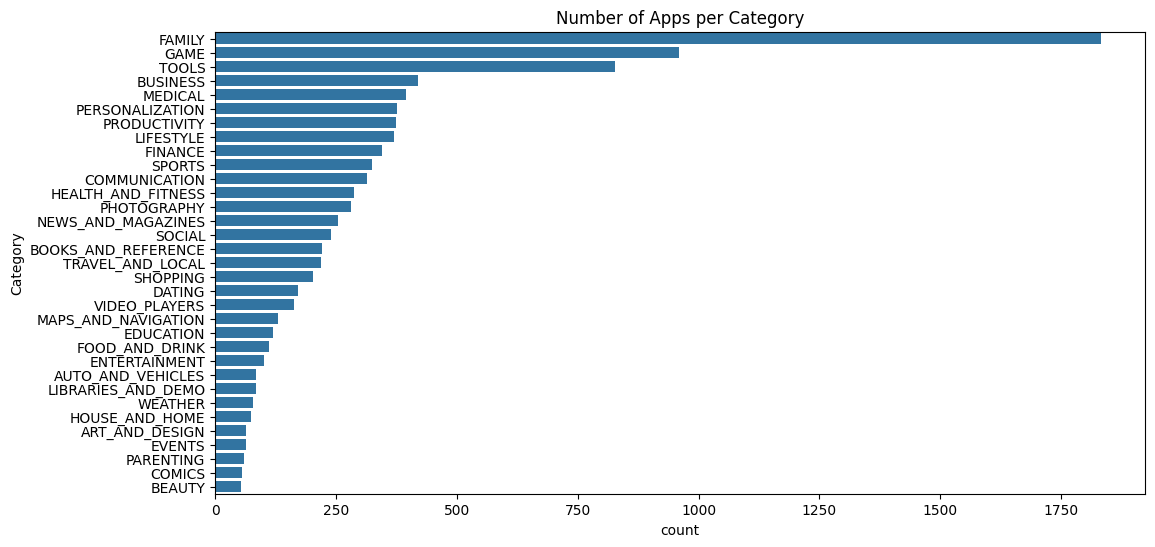


Average Rating per Category:
 Category
EDUCATION              4.362800
EVENTS                 4.357682
ART_AND_DESIGN         4.348746
BOOKS_AND_REFERENCE    4.303972
PERSONALIZATION        4.299237
PARENTING              4.278874
BEAUTY                 4.256711
GAME                   4.243736
WEATHER                4.236870
SOCIAL                 4.236137
HEALTH_AND_FITNESS     4.232370
SHOPPING               4.223819
SPORTS                 4.207572
AUTO_AND_VEHICLES      4.187987
PRODUCTIVITY           4.181408
COMICS                 4.181187
FAMILY                 4.178879
LIBRARIES_AND_DEMO     4.176963
FOOD_AND_DRINK         4.172485
MEDICAL                4.168330
PHOTOGRAPHY            4.158428
HOUSE_AND_HOME         4.153769
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.131741
COMMUNICATION          4.131179
BUSINESS               4.126427
FINANCE                4.122752
LIFESTYLE              4.108077
TRAVEL_AND_LOCAL       4.084675
TOOLS                  4.057175


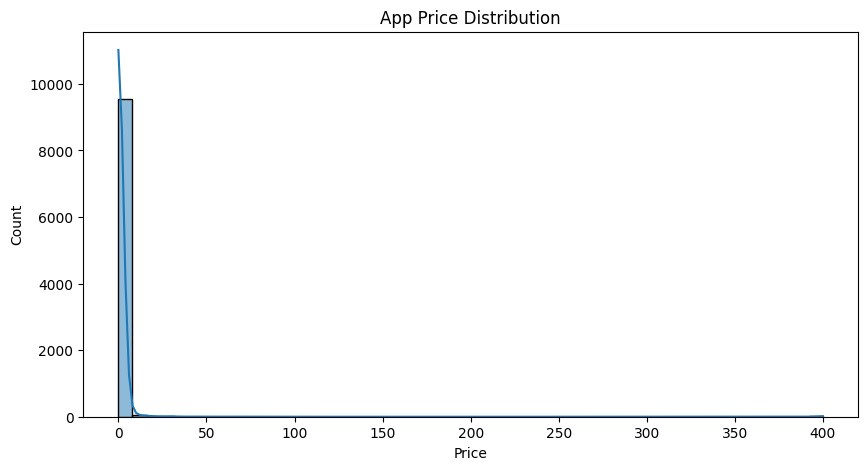


--- Reviews Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB
None

Sentiment Distribution:
Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64


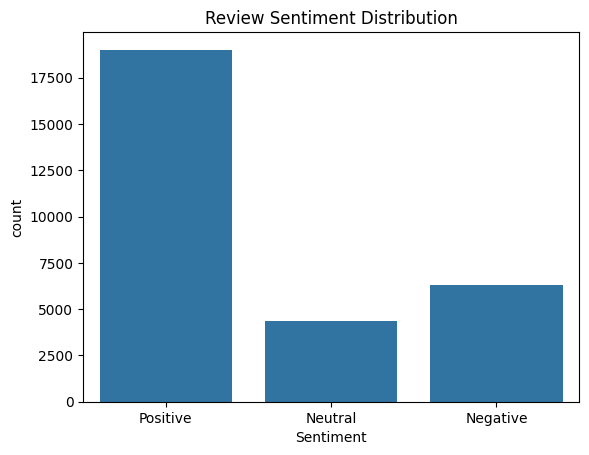

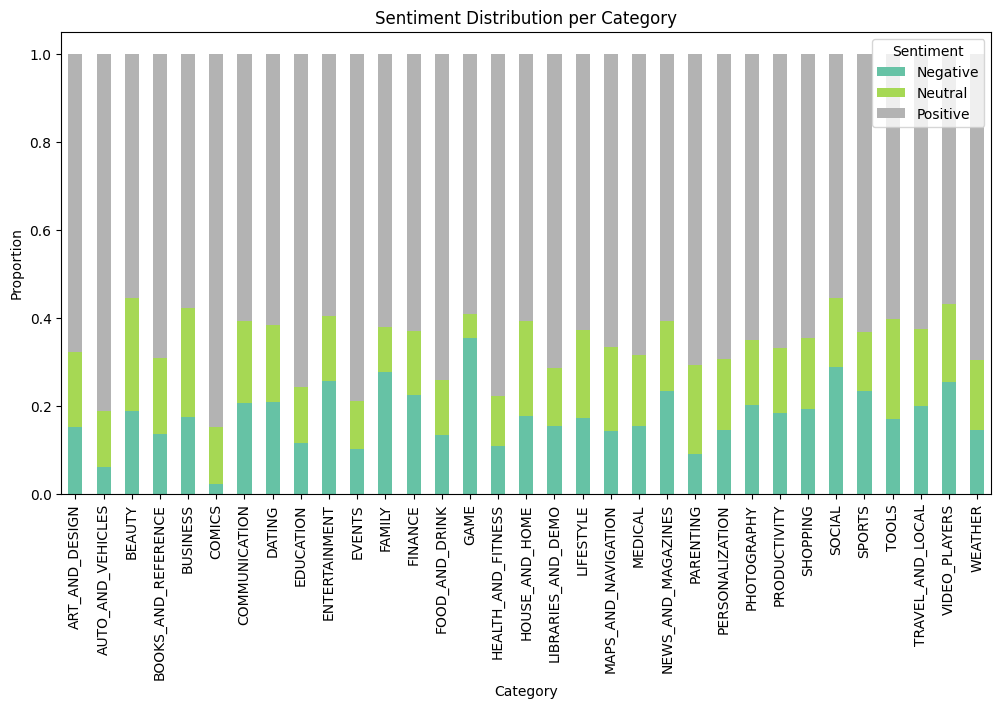

In [ ]:
print("\nApps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

# 4️⃣ Explore Apps dataset
print("\n--- Apps Dataset Info ---")
print(apps.info())

print("\n--- Missing Values ---")
print(apps.isnull().sum())

# 5️⃣ Clean Apps dataset
apps = apps.drop_duplicates()

# Convert Rating to numeric
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')
apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)

# Convert Size column
def convert_size(x):
    if 'M' in x:
        return float(x.replace('M','')) * 1024
    elif 'k' in x:
        return float(x.replace('k',''))
    else:
        return None

apps['Size'] = apps['Size'].astype(str)
apps['Size'] = apps['Size'].apply(convert_size)
apps['Size'].fillna(apps['Size'].mean(), inplace=True)

# Convert Installs to numeric
apps['Installs'] = apps['Installs'].str.replace('[+,]', '', regex=True).astype(float)

# Convert Price to numeric
apps['Price'] = apps['Price'].str.replace('$','').astype(float)
apps['Price'].fillna(0, inplace=True)

print("\nApps dataset cleaned!")

# 6️⃣ Category Exploration
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(y='Category', data=apps, order=apps['Category'].value_counts().index)
plt.title("Number of Apps per Category")
plt.show()

# Average rating per category
avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print("\nAverage Rating per Category:\n", avg_rating)

# 7️⃣ Metrics Analysis
top_rated = apps[['App','Rating','Reviews','Installs']].sort_values(by='Rating', ascending=False).head(10)
print("\nTop 10 Rated Apps:\n", top_rated)

plt.figure(figsize=(10,5))
sns.histplot(apps['Price'], bins=50, kde=True)
plt.title("App Price Distribution")
plt.show()

# 8️⃣ Sentiment Analysis on Reviews
print("\n--- Reviews Dataset Info ---")
print(reviews.info())

reviews = reviews.drop_duplicates()

print("\nSentiment Distribution:")
print(reviews['Sentiment'].value_counts())

sns.countplot(x='Sentiment', data=reviews)
plt.title("Review Sentiment Distribution")
plt.show()

# 9️⃣ Merge Reviews with Apps (optional)
merged = reviews.merge(apps[['App','Category']], on='App', how='left')
merged.head()

# Sentiment per category
sentiment_per_category = merged.groupby('Category')['Sentiment'].value_counts(normalize=True).unstack().fillna(0)
sentiment_per_category.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title("Sentiment Distribution per Category")
plt.ylabel("Proportion")
plt.show()

# 🔟 Optional Interactive Visualization
!pip install plotly --quiet
import plotly.express as px

fig = px.scatter(apps, x='Reviews', y='Rating', size='Installs', color='Category',
                 hover_data=['App'], title="App Rating vs Reviews vs Installs by Category")
fig.show()